In [7]:
import torch
from torch import nn #nn contains building blocks for nueral networks
import matplotlib.pyplot as plt

## 1. Preparing data

In [8]:
# linear reggresion
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [9]:
len(X), len(y)

(50, 50)

### Splitting data into training and test data


In [10]:
train_split = int(0.8 * len(X)) #80/20 rule
X_train, y_train = X[:train_split], y[:train_split] #80
X_test, y_test = X[train_split:], y[train_split:] #20

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [11]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predicitons=None):
    plt.figure(figsize=(10,7))

    # training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")

    # testing data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing Data")

    # are there predicitons
    if predicitons is not None:
        plt.scatter(test_data, predicitons, c="r", s=4, label="Predicitons")

    plt.legend(prop={"size": 14});



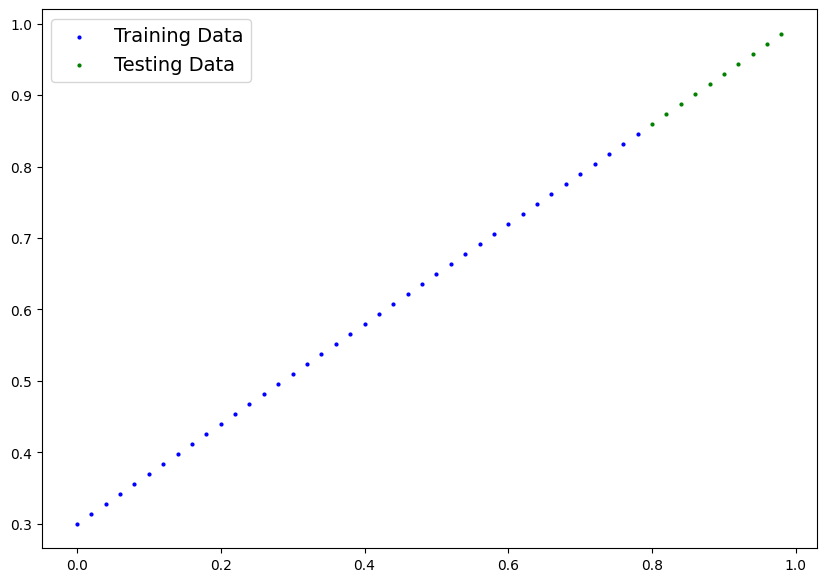

In [12]:
plot_predictions()

## 2. Build Model
* Gradient Descent
* Backpropagation

In [13]:
# linear regression model class
class LinearRergressionModel(nn.Module): # base class for all neural netwrok modules
    def __init__(self): 
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True, #defualt
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
        
    #Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: #x is the input data 
        #(FORWARD method is the computation that is done at every cell)
        return self.weights * x + self.bias #linear regres formula

### PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a nerual network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a pytorch layer from torch.nn will set these
* torch.nn.Module - The base class for all nerual modeules, if you subclass it, then overwrite forward()
* torch.optim - this is where the optimizers in pytorch live, they help with gradient descent
* def forward() - All nn.Module subcalsses requires to overwrite forward(), this method defines what happens in the forward computation

### Checking pytorch model

In [14]:
# random seed beacuse model uses randnumbers
torch.manual_seed(42)

# create an instance of the model (this is a sublcass of nn.Module)
model_0 = LinearRergressionModel()

# check out the params
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [15]:
# List named params
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
weight, bias

(0.7, 0.3)

### Making prediciton using `torch.inference_mode()`

See how well it predicts `y_test` based on `X_test`


In [17]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [18]:
# make predictions with model
with torch.inference_mode(): #disables grad = less memory (not needed during inference mode)
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [19]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

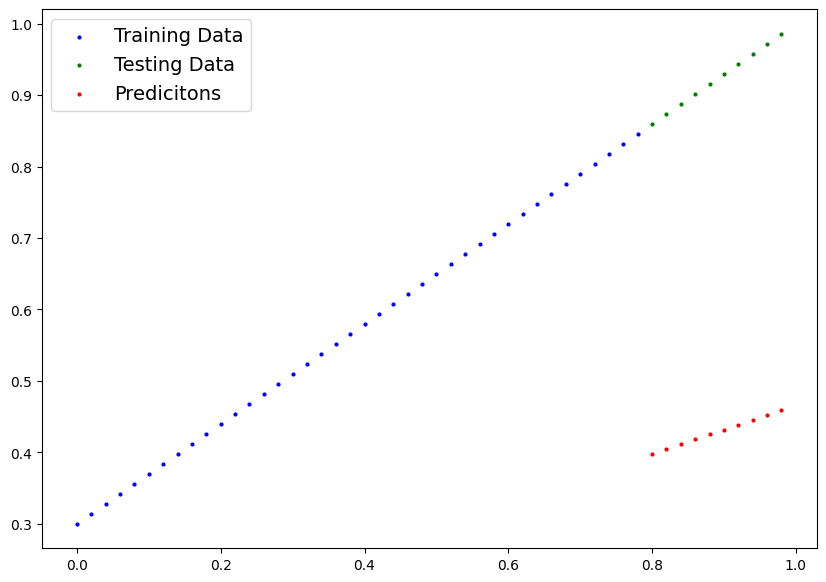

In [20]:
plot_predictions(predicitons=y_preds)

## 3. Train model
Need a way to now measure how poor or how wrong the model's predictions are, thats where loss functions come in

* Loss function may also be called cost function or criterion

Things we need to train

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias) to imporve the loss functiuon. 

And specifically for pytorch, we need: 
* A training loop
* A testing loop

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [22]:
# setup a loss function 
loss_fn = nn.L1Loss() #Mean Abs Error(mae)

# setup an optimizer (stochastic gradient descent (random numbers)) adjusts the params
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) #learning rate / alpha

### Building a training loop (and a testing loop) 
Things needed
1. loop through the data
2. forward pass (involves data moving through data's forward method) to make predictions on data - also called forward propagation
3. calcualte the loss(compare forward pass predictions)
4. optimizer zero grad
5. Loss backward- move backwards through the netwrok to calcualte the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
6. Optimizer step - use the optimizer to adjust our models parameters to try and imporve the loss (**gradient descent**)

In [23]:
torch.manual_seed(42)
epochs = 200

#track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
for epoch in range(epochs): 
    # set the model to training mode
    model_0.train() # train mode sets all parameteters that require gradients to require gradients

    #1. Forward pass
    y_preds = model_0(X_train)

    #2. Calcualte the loss 
    loss = loss_fn(y_preds, y_train)
    print(f"Loss: {loss}")

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Perform backpropagation on the loss with rpespect to the parameters of the model
    loss.backward() #by defualt how the optimizer changes will acculamte through the loop so.. we have to zero them for the next iteration (np.zeros i think but it zeros it)

    #5. Step the optimizer (perform gradient descent)
    optimizer.step() 

    ### Testing
    model_0.eval() # turns off differernt settings and stuff not needed for eval
    with torch.inference_mode(): #disables gradient tracking
        #1. forward pass on TEST DATA
        test_pred = model_0(X_test) 

        #2. calcualte the loss on TEST DATA 
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Test: {loss} | Test loss: {test_loss}")

    

Loss: 0.31288138031959534
Epoch: 0 | Test: 0.31288138031959534 | Test loss: 0.48106518387794495
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch: 10 | Test: 0.1976713240146637 | Test loss: 0.3463551998138428
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Test: 0.08908725529909134 | Test loss: 0.21729660034179688
Loss: 0.08227583020925522
Loss: 0.07638873159885406
Loss: 0.07160007208585739
Loss: 0.06747635453939438
Loss: 0.06395438313484192
Loss: 0.06097004935145378
Loss: 0.05845819041132927
Loss: 0.05635259300470352
Loss: 0.0545857772231102
Loss: 0.05314852669

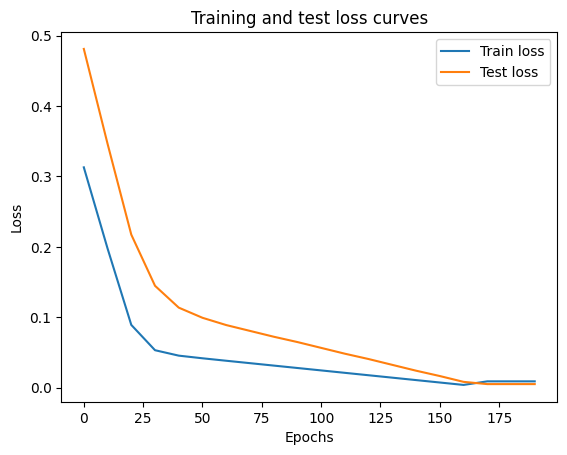

In [24]:
#plot loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [25]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [27]:
weight, bias

(0.7, 0.3)

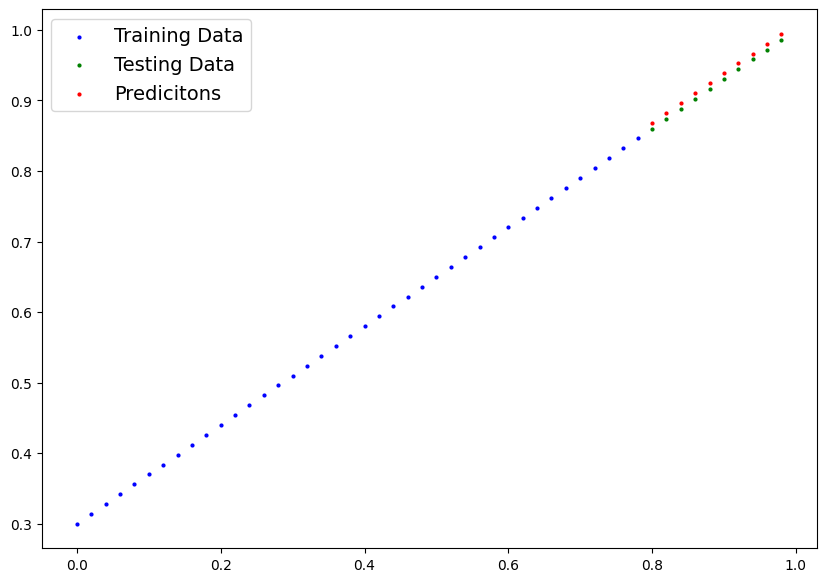

In [28]:
plot_predictions(predicitons=y_preds_new)

### Saving a model in pytorch 

Threee main methods

1. `torch.save()` - allows save via python pickle format
2. `torch.load()` - load saved pytorch obejct
3. `torch.nn.Module.load_state_dict()` - this allows to load a models saved state dictionary 

In [29]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [30]:
# Saving 
from pathlib import Path

#1. create models directiory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. create model save path
MODEL_NAME = "01_pytorch_model_0.pth" #pytorch file ext
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. save model (state.dict)
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_model_0.pth


### Loading a pytorch model

In [31]:
# load state dict
loaded_model_0 = LinearRergressionModel()

# Load the saved state_dict
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

C:\Users\fiore\AppData\Local\Temp\ipykernel_21500\4067715222.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)

<All keys matched successfully>

In [32]:
loaded_model_0.state_dict(), model_0.state_dict()

(OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))]),
 OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))]))

In [33]:
# Make predicitons
loaded_model_0.eval()
with torch.inference_mode(): 
    loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [34]:
loaded_model_0.eval()
with torch.inference_mode(): 
    y_preds = loaded_model_0(X_test)
y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [35]:
# compare loaded model preds with orginal preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 4. Putting it all together


In [36]:
import torch
from torch import nn
import matplotlib.pyplot as plt

Create device-agnostic code.

This means if we got access to gpu our code will use it

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 4.1 Data

In [66]:
weight = 0.7
bias = 0.3

start = 0 
end = 1
step = 0.02 

# x and y 
X = torch.arange(start, end, step).unsqueeze(dim=1) #unsqueeze without will cause erros
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [67]:
# split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(y_test), len(X_test)

(40, 40, 10, 10)

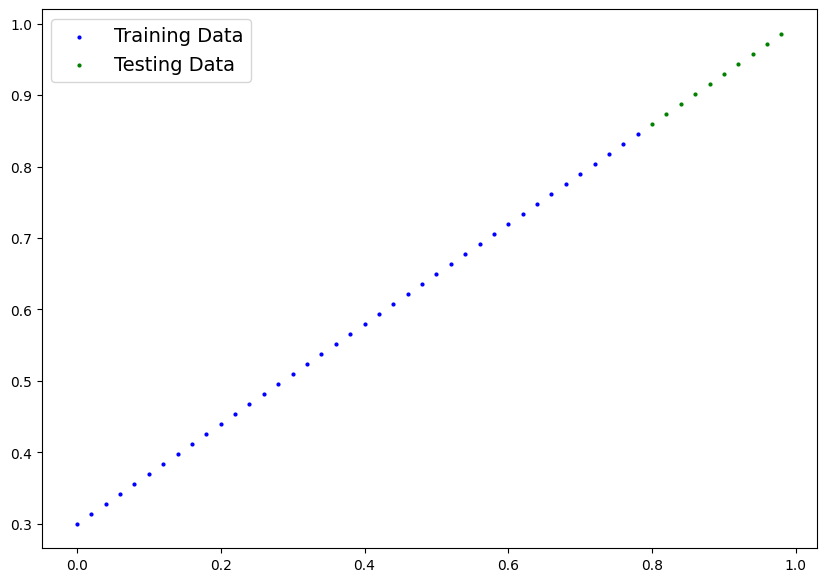

In [84]:
plot_predictions(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu())

### 4.2 building a pytorch linear model

In [85]:
class LinearRergressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

    #use nn.Linear() for creating model params
        self.linear_layer = nn.Linear(in_features=1, #one value of x equates to one value of y in the tensor #torch.tensor = x [[0.2313]] y [[0.0220]]
                                    out_features=1) #one value of x equates to one value of y in the tesnor 
        """
        Converted the self.weight and self.bias 
        to this this does it automaticly USING (LINEAR LAYER)
        """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set seed 
torch.manual_seed(42)
model_1 = LinearRergressionModelV2()
model_1, model_1.state_dict()

(LinearRergressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [86]:
# check model device
next(model_1.parameters()).device

device(type='cpu')

In [87]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 4.3 Training 

For Training we need: 

* Loss Function
* Optimizer
* Training loop
* Testing loop

In [88]:
# loss function 
loss_fn = nn.L1Loss() # same as mae

# setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [89]:
# training loop
torch.manual_seed(42)

epochs = 200

#put data on target device
X_train = X_train.to(device) 
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs): 
    model_1.train()

    #1. forward pass
    y_pred = model_1(X_train)

    #2. Loss
    loss = loss_fn(y_pred, y_train)

    #3. zero optimizer
    optimizer.zero_grad()

    #4. Backpropagation 
    loss.backward()

    #5. optimizer step
    optimizer.step()

    ### testing
    model_1.eval()
    with torch.inference_mode(): 
        test_pred = model_1(X_test) 

        test_loss = loss_fn(test_pred, y_test)

    #print output
    if epoch % 10 == 0: 
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}") 

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.439968079328537 | Test Loss: 0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test Loss: 0.16984669864177704
Epoch: 40 | Loss: 0.09433845430612564 | Test Loss: 0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test Loss: 0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test Loss: 0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test Loss: 0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test Loss: 0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test Loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416

In [90]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

### 4.4 Making and evaulting predictions

In [91]:
# turn model into eval mode
model_1.eval() 

# make predictions on test data
with torch.inference_mode(): 
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

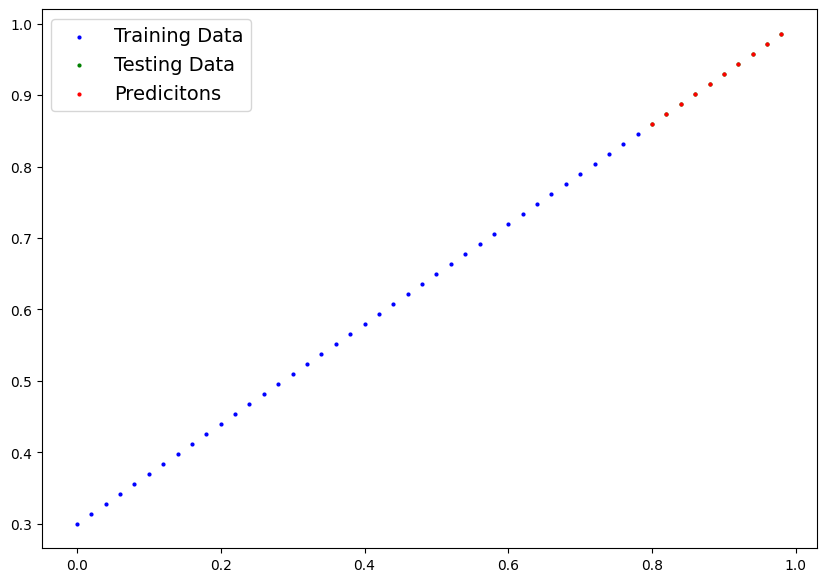

In [92]:
#check data visually
plot_predictions(predicitons=y_preds.cpu())

### 4.5 Saving & loading model

In [96]:
from pathlib import Path

#create dir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. model save path
MODEL_NAME = "01_pytorch_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. save model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_model_1.pth


In [95]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [97]:
# Load a pyttorch model

#create new instance
loaded_model_1 = LinearRergressionModelV2()

# load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put loaded model to device
loaded_model_1.to(device)

C:\Users\fiore\AppData\Local\Temp\ipykernel_21500\3336878220.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))


LinearRergressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [98]:
next(loaded_model_1.parameters())

Parameter containing:
tensor([[0.6968]], device='cuda:0', requires_grad=True)

In [99]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [100]:
# Eval loadded model
loaded_model_1.eval() 
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

## 5. Excercises


In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt 
import torch
from torch import nn


In [2]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used is: {device}")

Device used is: cuda


### 1. Create a straight line dataset using the linear regression formula (weight * X + bias).
* Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.
* Split the data into 80% training, 20% testing.
* Plot the training and testing data so it becomes visual.
Your output of the below cell should look something like:

```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```
Of course the numbers in X and y may be different but ideally they're created using the linear regression formula.

In [3]:
# Create the data parameters
weight = 0.3
bias = 0.9
X = torch.arange(0, 1, .01).unsqueeze(dim=1)
y = weight * X + bias
# Make X and y using linear regression feature


print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [5]:
# Split the data into training and testing
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], X[:train_split]
X_test, y_test = X[train_split:], X[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [6]:
# Plot the training and testing data 
def plot_predictionsV2(train_data=X_train, 
                       train_labels=y_train, 
                       test_data=X_test, 
                       test_lables=y_test, 
                       predictions=None):
    plt.figure(figsize=(10,7))

    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")

    plt.scatter(test_data, test_lables, c="r", s=4, label="Testing Data")

    if predictions is not None: 
        plt.scatter(test_data, predictions, c="g",s=4, label="Predictions")
    
    plt.legend(prop={"size": 14});

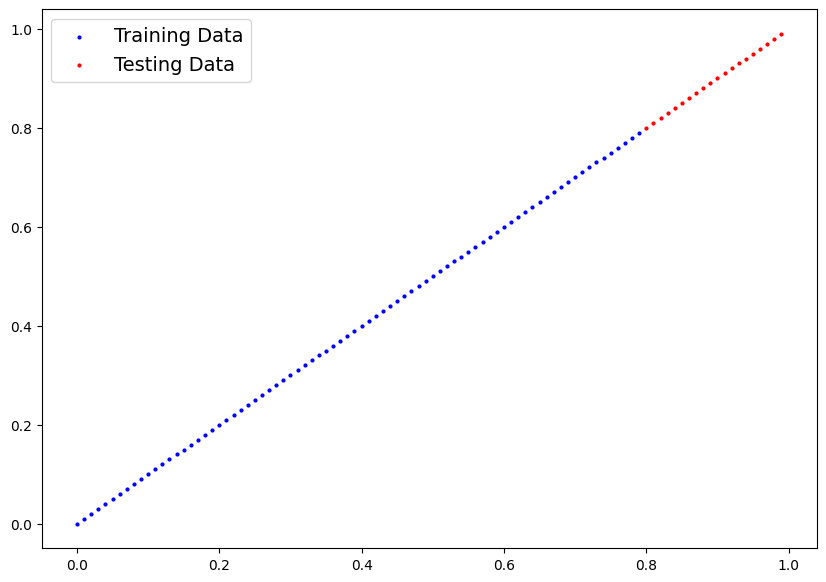

In [7]:
plot_predictionsV2()

### 2. Build a PyTorch model by subclassing nn.Module.
* Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.
* Implement the forward() method to compute the linear regression function you used to create the dataset in 1.
* Once you've constructed the model, make an instance of it and check its state_dict().
* **Note:** If you'd like to use nn.Linear() instead of nn.Parameter() you can.

In [10]:
class LinearRegressionV3(nn.Module): 
    def __init__(self):
        super().__init__()
        
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.linear_layer(x)

torch.manual_seed(42)
model_2 = LinearRegressionV3()
model_2.state_dict(), model_2


(OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]),
 LinearRegressionV3(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ))

In [11]:
next(model_2.parameters()).device

device(type='cpu')

In [12]:
model_2 = model_2.to(device)
next(model_2.parameters()).device

device(type='cuda', index=0)

### 3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.
* Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
* Write a training loop to perform the appropriate training steps for 300 epochs.
* The training loop should test the model on the test dataset every 20 epochs.

In [13]:
# Create the loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [16]:
# Training loop
torch.manual_seed(42)
epochs = 300
epoch_count = []
loss_values = []
test_loss_values = []

# Send data to target device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  ### Training

  # Put model in train mode
  model_2.train()

  # 1. Forward pass
  y_pred = model_2(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_pred, y_train)

  # 3. Zero gradients
  optimizer.zero_grad()

  # 4. Backpropagation
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Perform testing every 20 epochs
  if epoch % 20 == 0:

    # Put model in evaluation mode and setup inference context 
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      y_preds = model_2(X_test)
      # 2. Calculate test loss
      test_loss = loss_fn(y_preds, y_test)
      # Print out what's happening
      epoch_count.append(epoch)
      loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.763 | Test loss: 1.049
Epoch: 20 | Train loss: 0.532 | Test loss: 0.778
Epoch: 40 | Train loss: 0.301 | Test loss: 0.508
Epoch: 60 | Train loss: 0.097 | Test loss: 0.257
Epoch: 80 | Train loss: 0.061 | Test loss: 0.157
Epoch: 100 | Train loss: 0.053 | Test loss: 0.126
Epoch: 120 | Train loss: 0.046 | Test loss: 0.109
Epoch: 140 | Train loss: 0.040 | Test loss: 0.093
Epoch: 160 | Train loss: 0.033 | Test loss: 0.076
Epoch: 180 | Train loss: 0.026 | Test loss: 0.060
Epoch: 200 | Train loss: 0.019 | Test loss: 0.044
Epoch: 220 | Train loss: 0.012 | Test loss: 0.028
Epoch: 240 | Train loss: 0.005 | Test loss: 0.012
Epoch: 260 | Train loss: 0.009 | Test loss: 0.001
Epoch: 280 | Train loss: 0.009 | Test loss: 0.001


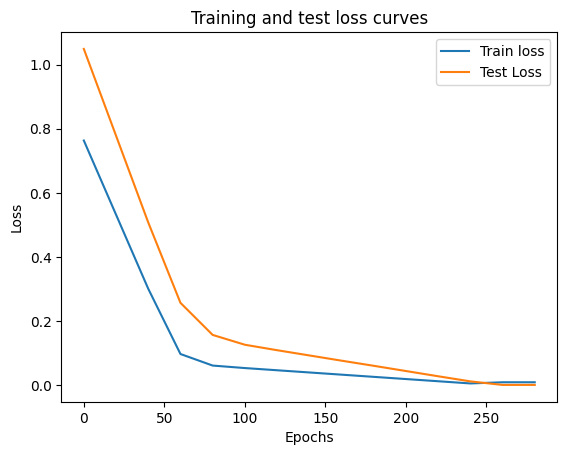

In [19]:
import numpy as np

plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

### 4. Make predictions

In [20]:
# Make predictions with the model
model_2.eval()

with torch.inference_mode():
    y_preds = model_2(X_test)
y_preds

tensor([[0.7879],
        [0.7978],
        [0.8077],
        [0.8177],
        [0.8276],
        [0.8375],
        [0.8474],
        [0.8574],
        [0.8673],
        [0.8772],
        [0.8871],
        [0.8971],
        [0.9070],
        [0.9169],
        [0.9268],
        [0.9368],
        [0.9467],
        [0.9566],
        [0.9665],
        [0.9765]], device='cuda:0')

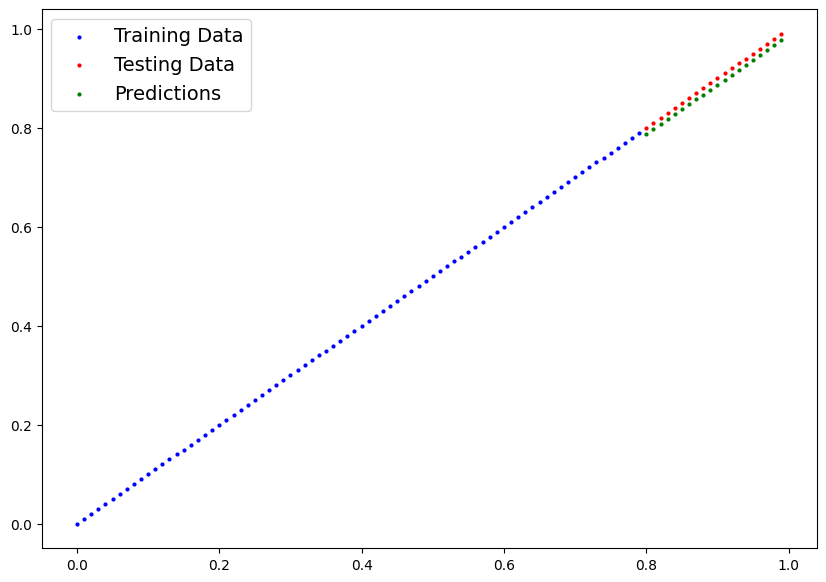

In [21]:
plot_predictionsV2(predictions=y_preds.cpu())

### 5.Save your trained model's state_dict() to file. 

In [22]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

In [23]:
model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.9924]], device='cuda:0')),
             ('linear_layer.bias', tensor([-0.0060], device='cuda:0'))])

In [24]:
loaded_model_2 = LinearRegressionV3()
loaded_model_2.state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2.to(device)

C:\Users\fiore\AppData\Local\Temp\ipykernel_12332\1014735464.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_2.state_dict(torch.load(f=MODEL_SAVE_PATH))
C:\

LinearRegressionV3(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [27]:
y_preds_new = loaded_model_2(X_test)
y_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

In [28]:
loaded_model_2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.8300], device='cuda:0'))])